In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dating-app-behavior-dataset/dating_app_behavior_dataset.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [3]:
data = pd.read_csv("/kaggle/input/dating-app-behavior-dataset/dating_app_behavior_dataset.csv")

In [4]:
data.head()

,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,173,23,4,44,75,0.36,13,Early Morning,Mutual Match
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,107,7,3,301,35,0.42,0,Morning,Chat Ignored
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,91,27,2,309,33,0.41,1,After Midnight,Date Happened
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,147,6,5,35,5,0.07,21,Morning,No Action
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,94,11,1,343,34,0.11,22,After Midnight,One-sided Like


In [5]:
data.tail()

,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome
49995,Transgender,Gay,Metro,Very High,Postdoc,"Gaming, Writing, Painting",130,Addicted,0.69,Optimistic,99,8,5,235,9,0.19,15,Afternoon,Ghosted
49996,Female,Lesbian,Small Town,Low,Diploma,"Traveling, Fitness, Stand-up Comedy",277,Extreme User,0.43,Optimistic,173,1,1,278,69,0.23,2,Evening,Ghosted
49997,Male,Bisexual,Remote Area,High,High School,"Gaming, Motorcycling, Art",73,High,0.50,Optimistic,123,8,1,128,94,0.36,5,After Midnight,Blocked
49998,Transgender,Queer,Urban,Low,MBA,"Skating, Astrology, Hiking",100,High,0.34,Balanced,149,19,3,206,53,0.36,16,Evening,One-sided Like
49999,Prefer Not to Say,Pansexual,Metro,Lower-Middle,Bachelor’s,"Crafting, Spirituality, Coding",119,High,0.56,Optimistic,114,17,0,395,68,0.50,16,Early Morning,No Action


In [6]:
# Display basic information about the dataset
print("Data Shape:", data.shape)  # Check the shape of the dataset (rows, columns)
print("Columns:", data.columns)  # Check the column names
print("Data Types:\n", data.dtypes)  # Check the data types of each column


Data Shape: (50000, 19)
Columns: Index(['gender', 'sexual_orientation', 'location_type', 'income_bracket',
       'education_level', 'interest_tags', 'app_usage_time_min',
       'app_usage_time_label', 'swipe_right_ratio', 'swipe_right_label',
       'likes_received', 'mutual_matches', 'profile_pics_count', 'bio_length',
       'message_sent_count', 'emoji_usage_rate', 'last_active_hour',
       'swipe_time_of_day', 'match_outcome'],
      dtype='object')
Data Types:
 gender                   object
sexual_orientation       object
location_type            object
income_bracket           object
education_level          object
interest_tags            object
app_usage_time_min        int64
app_usage_time_label     object
swipe_right_ratio       float64
swipe_right_label        object
likes_received            int64
mutual_matches            int64
profile_pics_count        int64
bio_length                int64
message_sent_count        int64
emoji_usage_rate        float64
last_active_ho

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender                50000 non-null  object 
 1   sexual_orientation    50000 non-null  object 
 2   location_type         50000 non-null  object 
 3   income_bracket        50000 non-null  object 
 4   education_level       50000 non-null  object 
 5   interest_tags         50000 non-null  object 
 6   app_usage_time_min    50000 non-null  int64  
 7   app_usage_time_label  50000 non-null  object 
 8   swipe_right_ratio     50000 non-null  float64
 9   swipe_right_label     50000 non-null  object 
 10  likes_received        50000 non-null  int64  
 11  mutual_matches        50000 non-null  int64  
 12  profile_pics_count    50000 non-null  int64  
 13  bio_length            50000 non-null  int64  
 14  message_sent_count    50000 non-null  int64  
 15  emoji_usage_rate   

In [8]:
data.index

RangeIndex(start=0, stop=50000, step=1)

In [9]:
data.values

array([['Prefer Not to Say', 'Gay', 'Urban', ..., 13, 'Early Morning',
        'Mutual Match'],
       ['Male', 'Bisexual', 'Suburban', ..., 0, 'Morning',
        'Chat Ignored'],
       ['Non-binary', 'Pansexual', 'Suburban', ..., 1, 'After Midnight',
        'Date Happened'],
       ...,
       ['Male', 'Bisexual', 'Remote Area', ..., 5, 'After Midnight',
        'Blocked'],
       ['Transgender', 'Queer', 'Urban', ..., 16, 'Evening',
        'One-sided Like'],
       ['Prefer Not to Say', 'Pansexual', 'Metro', ..., 16,
        'Early Morning', 'No Action']], dtype=object)

In [10]:
data.shape

(50000, 19)

In [11]:
data.size

950000

In [12]:
# Check for missing values
print("Missing Values:\n", data.isnull().sum()) 

Missing Values:
 gender                  0
sexual_orientation      0
location_type           0
income_bracket          0
education_level         0
interest_tags           0
app_usage_time_min      0
app_usage_time_label    0
swipe_right_ratio       0
swipe_right_label       0
likes_received          0
mutual_matches          0
profile_pics_count      0
bio_length              0
message_sent_count      0
emoji_usage_rate        0
last_active_hour        0
swipe_time_of_day       0
match_outcome           0
dtype: int64


In [13]:
data.describe

<bound method NDFrame.describe of                   gender sexual_orientation location_type income_bracket  \
0      Prefer Not to Say                Gay         Urban           High   
1                   Male           Bisexual      Suburban   Upper-Middle   
2             Non-binary          Pansexual      Suburban            Low   
3            Genderfluid                Gay         Metro       Very Low   
4                   Male           Bisexual         Urban         Middle   
...                  ...                ...           ...            ...   
49995        Transgender                Gay         Metro      Very High   
49996             Female            Lesbian    Small Town            Low   
49997               Male           Bisexual   Remote Area           High   
49998        Transgender              Queer         Urban            Low   
49999  Prefer Not to Say          Pansexual         Metro   Lower-Middle   

           education_level                        int

In [14]:
data.columns

Index(['gender', 'sexual_orientation', 'location_type', 'income_bracket',
       'education_level', 'interest_tags', 'app_usage_time_min',
       'app_usage_time_label', 'swipe_right_ratio', 'swipe_right_label',
       'likes_received', 'mutual_matches', 'profile_pics_count', 'bio_length',
       'message_sent_count', 'emoji_usage_rate', 'last_active_hour',
       'swipe_time_of_day', 'match_outcome'],
      dtype='object')

# VISUALIZATION

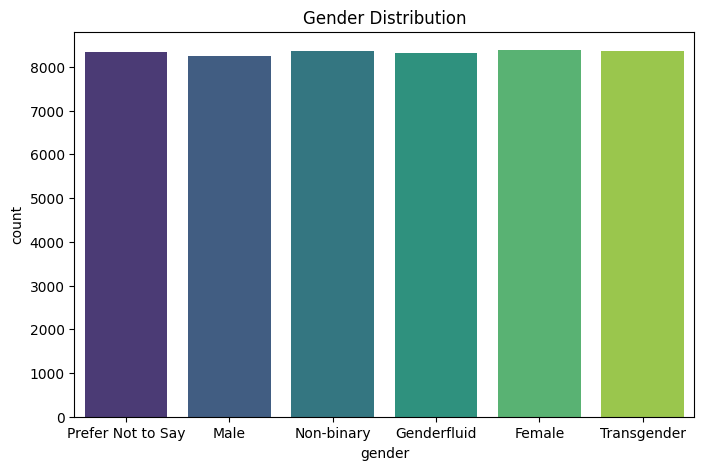

In [15]:
# Gender Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='gender', data=data, palette='viridis')
plt.title('Gender Distribution')
plt.show()

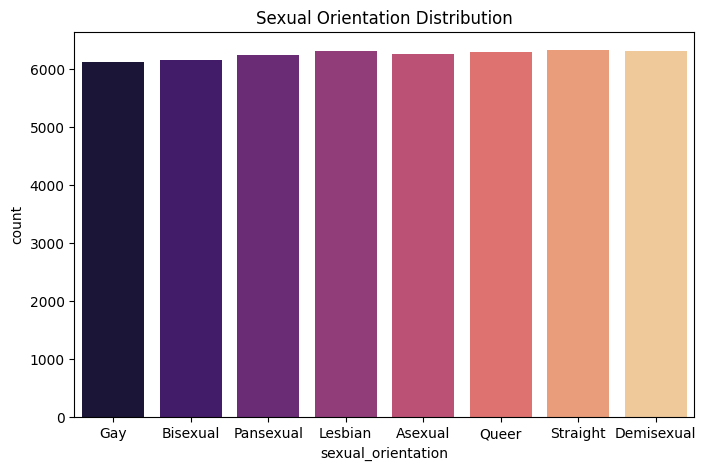

In [16]:
# Sexual Orientation Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='sexual_orientation', data=data, palette='magma')
plt.title('Sexual Orientation Distribution')
plt.show()


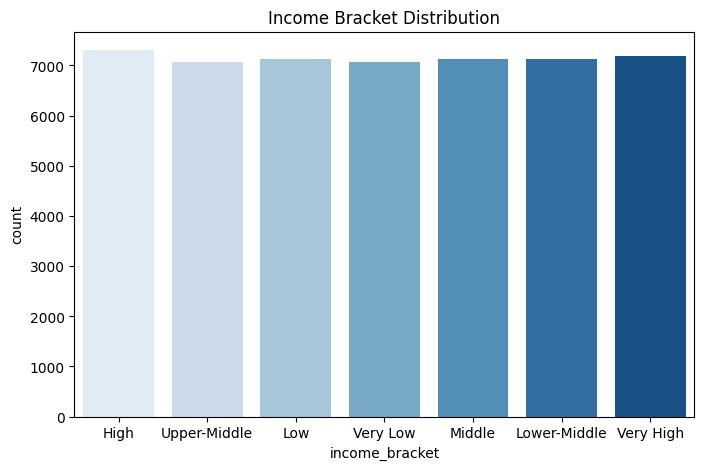

In [17]:
# Income Bracket Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='income_bracket', data=data, palette='Blues')
plt.title('Income Bracket Distribution')
plt.show()


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


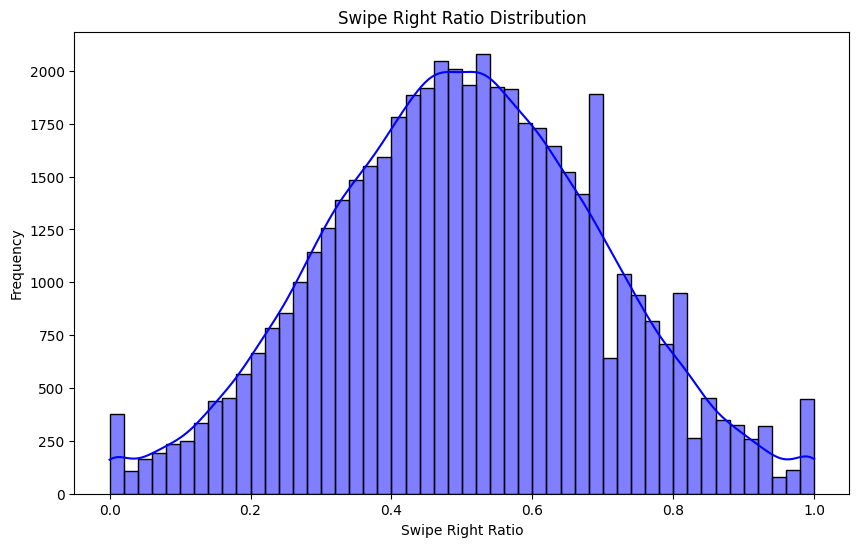

In [18]:
# Swipe Right Ratio Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['swipe_right_ratio'], bins=50, kde=True, color='blue')
plt.title('Swipe Right Ratio Distribution')
plt.xlabel('Swipe Right Ratio')
plt.ylabel('Frequency')
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


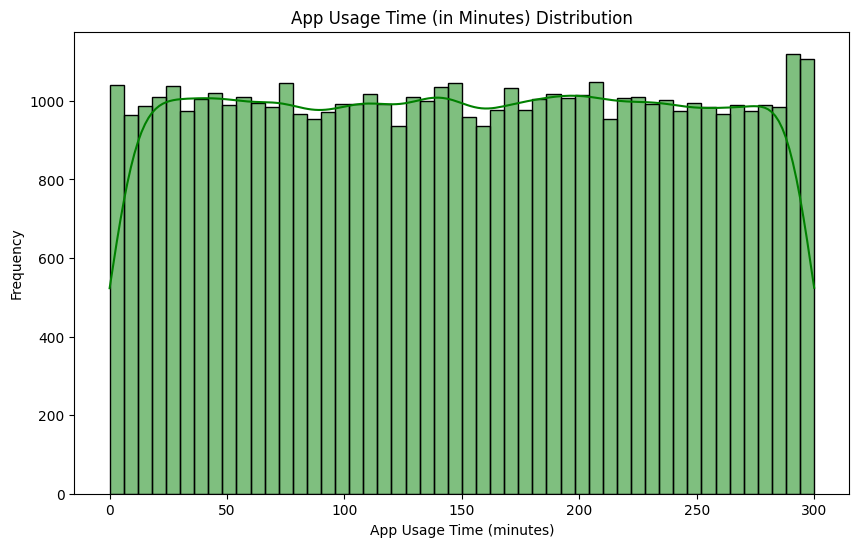

In [19]:
# App Usage Time Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['app_usage_time_min'], bins=50, kde=True, color='green')
plt.title('App Usage Time (in Minutes) Distribution')
plt.xlabel('App Usage Time (minutes)')
plt.ylabel('Frequency')
plt.show()

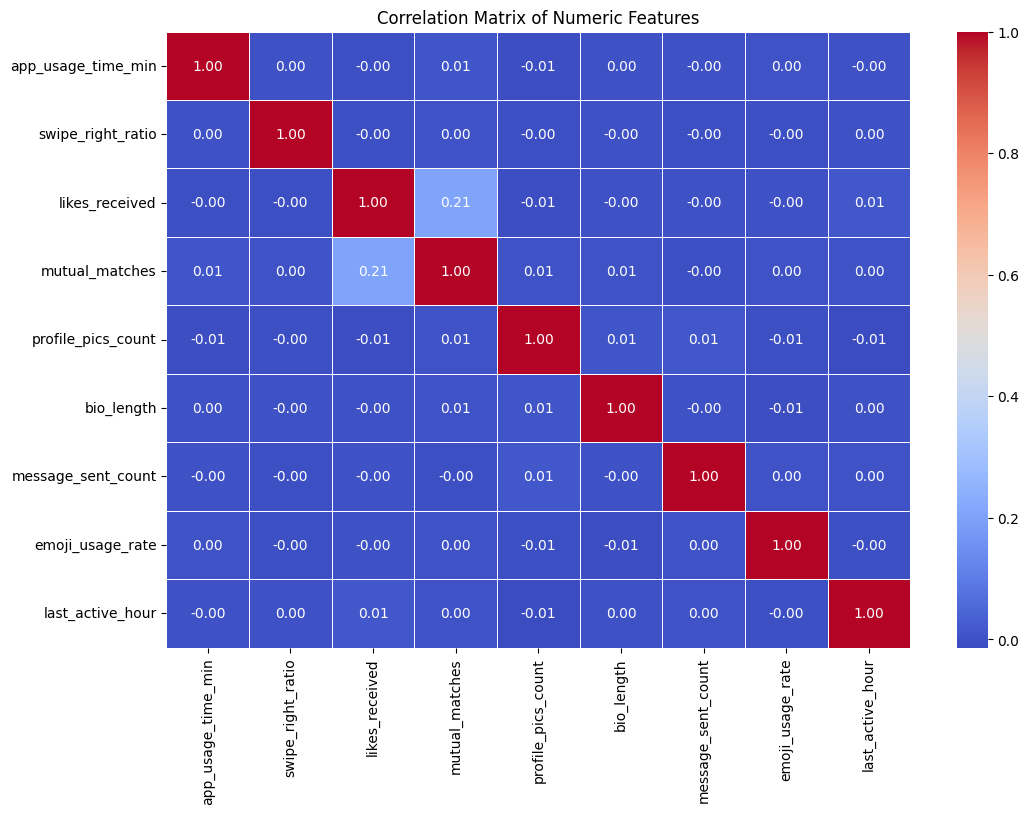

In [20]:
# Select only numeric columns for correlation matrix
numeric_data = data.select_dtypes(include=['float64', 'int64'])

# Compute the correlation matrix
correlation_matrix = numeric_data.corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()


# Conclusion
In this analysis, we explored user behavior on a fictional dating app using synthetic data. We found interesting correlations between user demographics, app usage patterns, and match success. For example, users with higher income levels tended to engage more frequently with the app, and those with an optimistic swipe right ratio had higher chances of mutual matches.

Further analysis could focus on building more advanced predictive models to forecast user engagement or even detecting behaviors like ghosting or catfishing.

Possible next steps:
1. Improving model accuracy by tuning hyperparameters.
2. Investigating deeper into behavioral patterns based on app usage time.
3. Studying the influence of interests or hobbies on match success.

This notebook serves as a starting point for further research into user behavior in online dating platforms.
